In [97]:
# Animation of four bar

import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import fsolve
import matplotlib.animation as animation
import math
from matplotlib.animation import FuncAnimation

%matplotlib widget

In [98]:
# Example analysis of a four-bar mechanism.

# Data initialization (all data is in SI units)
# kinematic parameters (link lengths)
import math

r1 = 0.2 #m
r2 = r1 #m
r3 = 0.2 #m
r4 = r3 #m
r5 = 0.1 #m
r6 = r5 #m
r7_1 = 0.1 #m
r7_2 = 0.3 #m
r7 = r7_1 + r7_2 #m
r8 = 0.4 #m
r9 = r8 #m
r10_1 = r7_1 #m
r10_2 = r7_2 #m
r10 = r10_1 + r10_2 #m
phi10 = math.pi/2 #rad
g = 9.81  # gravity acceleration [m/s^2]
c = 0.05


In [99]:
# STEP 1. Determination of Kinematics

# position analysis
phi1_init = 0.2  # initial condition for first step of position analysis with fsolve (phi3 and phi4)
phi2_init = 2  # VERY IMPORTANT because it determines which branch of the mechanism you're in
phi3_init = 0.2
phi4_init = 2
phi5_init = 0.2
phi6_init = 2
phi7_init = math.pi/2
phi8_init = 2

t_begin =  0     # start time of simulation
t_end   = 45     # end time of simulation
Ts      =  0.1  # time step of simulation
T= Ts*t_end
t = np.arange(t_begin, t_end + Ts, Ts)  # time vector

phi9_min = np.radians(35)    # "almost 0" — stay away from singularity
phi9_max = np.radians(85)   # "fully extended" — stay away from phi=pi too

# initialization of driver
omega = 0.7      # driver frequency
A     = (phi9_max - phi9_min) / 2      # amplitude
# angular position, velocity and acceleration:
phi9   = (phi9_min + phi9_max) / 2 + A * np.sin(omega * t)
dphi9  = omega * A * np.cos(omega * t)
ddphi9 = -omega ** 2 * A * np.sin(omega * t)

#phi9_min = np.radians(5)    # "almost 0" — stay away from singularity
#phi9_max = np.radians(65)   # "fully extended" — stay away from phi=pi too

# Cosine motion law (smooth start/stop, zero velocity at endpoints)
#phi9 = phi9_min + 0.5 * (phi9_max - phi9_min) * (1 - np.cos(2 * np.pi * t / T))

# Derivatives (analytical, no numerical noise)
#dphi9  =      0.5 * (phi9_max - phi9_min) * (2*np.pi/T) * np.sin(2 * np.pi * t / T)
#ddphi9 =      0.5 * (phi9_max - phi9_min) * (2*np.pi/T)**2 * np.cos(2 * np.pi * t / T)
print(np.degrees(phi9))

[60.         61.74857118 63.48857787 65.2114975  66.90889121 68.57244519
 70.19401133 71.7656472  73.27965495 74.72861895 76.10544218 77.40338097
 78.616078   79.73759349 80.76243426 81.68558064 82.50251105 83.20922418
 83.80225854 84.27870945 84.63624325 84.87310874 84.98814577 84.98079086
 84.85108005 84.59964867 84.22772822 83.73714037 83.13028802 82.41014353
 81.58023417 80.64462483 79.60789813 78.47513195 77.25187459 75.94411755
 74.55826624 73.10110854 71.57978162 70.00173694 68.37470375 66.70665127
 65.00574962 63.2803298  61.53884294 59.78981882 58.04182416 56.30342065
 54.58312299 52.88935719 51.23041931 49.61443483 48.04931885 46.54273729
 45.1020694  43.73437157 42.44634278 41.24429179 40.13410626 39.12122386
 38.21060569 37.40671197 36.71348016 36.13430571 35.67202542 35.32890354
 35.10662067 35.00626557 35.02832976 35.17270518 35.43868468 35.82496549
 36.32965561 36.95028306 37.68380801 38.52663766 39.47464383 40.52318318
 41.66711998 42.9008512  44.21833405 45.6131155  47

In [ ]:
# Function to rotate a vector z over an angle theta:
def rotate_vector(z, theta):
    rotation_matrix = np.array([[np.cos(theta), -np.sin(theta)],
                                [np.sin(theta), np.cos(theta)]])
    return np.dot(rotation_matrix, z)

# Calculate the acceleration of a bar endpoint in global x/y coordinates.
# pivot: 2-element array of the pivot point position
# length: scalar length of the bar
# phi: bar angle with respect to global x-axis [rad]
# dphi: angular velocity [rad/s]
# ddphi: angular acceleration [rad/s^2]
# pivot_acc: optional pivot acceleration in global coordinates
# Returns: numpy array([a_x, a_y])
def bar_endpoint_acceleration(pivot, length, phi, dphi, ddphi, pivot_acc=None):
    if pivot_acc is None:
        pivot_acc = np.zeros(2)
    ax = pivot_acc[0] - length * np.cos(phi) * dphi**2 - length * np.sin(phi) * ddphi
    ay = pivot_acc[1] - length * np.sin(phi) * dphi**2 + length * np.cos(phi) * ddphi
    return np.array([ax, ay])

# Calculate the acceleration of a bar's center of mass, assuming the mass center is at the midpoint.
# The bar angle phi is still measured from the horizontal x-axis.
def bar_midpoint_acceleration(pivot, length, phi, dphi, ddphi, pivot_acc=None):
    return bar_endpoint_acceleration(pivot, length / 2.0, phi, dphi, ddphi, pivot_acc=pivot_acc)


In [101]:
# Define loop closure equations
def loop_closure_eqs(phi_init, phi9, r1, r2, r3, r4, r5, r6, r7, r7_1, r8, r9, r10, r10_1, phi10):
    phi1 = phi_init[0]
    phi2 = phi_init[1]
    phi3 = phi_init[2]
    phi4 = phi_init[3]
    phi5 = phi_init[4]
    phi6 = phi_init[5]
    phi7 = phi_init[6]
    phi8 = phi_init[7]
    
    # Loop closure equations
    F1 = r1 * np.cos(phi1) - r3 * np.cos(phi3) - r5 * np.cos(phi5)+ r10_1 * np.cos(phi10)
    F2 = r1 * np.sin(phi1) - r3 * np.sin(phi3) - r5 * np.sin(phi5) + r10_1 * np.sin(phi10)
    F3 = r2 * np.cos(phi2) - r4 * np.cos(phi4) - r6 * np.cos(phi6) + r7_1 * np.cos(phi7)
    F4 = r2 * np.sin(phi2) - r4 * np.sin(phi4) - r6 * np.sin(phi6) + r7_1 * np.sin(phi7)
    F5 = r3 * np.cos(phi3) - r2 * np.cos(phi2) - r7 * np.cos(phi7) + r8 * np.cos(phi8)
    F6 = r3 * np.sin(phi3) - r2 * np.sin(phi2) - r7 * np.sin(phi7) + r8 * np.sin(phi8)
    F7 = r4 * np.cos(phi4) - r1 * np.cos(phi1) - r10 * np.cos(phi10) + r9 * np.cos(phi9)
    F8 = r4 * np.sin(phi4) - r1 * np.sin(phi1) - r10 * np.sin(phi10) + r9 * np.sin(phi9)

    return [F1, F2, F3, F4, F5, F6, F7, F8]

In [102]:
# Define kinematic computations of the four-bar mechanism

def kinematics_4bar(r1, r2, r3, r4, r5, r6, r7, r7_1, r8, r9, r10, r10_1, phi10, phi9, dphi9, ddphi9, phi1_init, phi2_init, phi3_init, phi4_init, phi5_init, phi6_init, phi7_init, phi8_init, t):
    global phi1, phi2, phi3, phi4, phi5, phi6, phi7, phi8, dphi1, dphi2, dphi3, dphi4, dphi5, dphi6, dphi7, dphi8, ddphi1, ddphi2, ddphi3, ddphi4, ddphi5, ddphi6, ddphi7, ddphi8
    phi1   = np.zeros_like(t)
    phi2   = np.zeros_like(t)
    phi3   = np.zeros_like(t)
    phi4   = np.zeros_like(t)
    phi5   = np.zeros_like(t)
    phi6   = np.zeros_like(t)
    phi7   = np.zeros_like(t)
    phi8   = np.zeros_like(t)
    dphi1  = np.zeros_like(t)
    dphi2  = np.zeros_like(t)
    dphi3  = np.zeros_like(t)
    dphi4  = np.zeros_like(t)
    dphi5  = np.zeros_like(t)
    dphi6  = np.zeros_like(t)
    dphi7  = np.zeros_like(t)
    dphi8  = np.zeros_like(t)
    ddphi1 = np.zeros_like(t)
    ddphi2 = np.zeros_like(t)
    ddphi3 = np.zeros_like(t)
    ddphi4 = np.zeros_like(t)
    ddphi5 = np.zeros_like(t)
    ddphi6 = np.zeros_like(t)
    ddphi7 = np.zeros_like(t)
    ddphi8 = np.zeros_like(t)
    cond   = np.zeros_like(t)
    optim_options = {"full_output":True}  # options for fsolve

    for k, time in enumerate(t):
        # Position Analysis
        x, _, ier, message  = fsolve(lambda x: loop_closure_eqs(x, phi9[k], r1, r2, r3, r4, r5, r6, r7, r7_1, r8, r9, r10, r10_1, phi10), [phi1_init, phi2_init, phi3_init, phi4_init, phi5_init, phi6_init, phi7_init, phi8_init], **optim_options)

        if ier != 1:
            print("The fsolve exit flag was not 1, probably no convergence!")
            print(message)

        phi1[k] = x[0]
        phi2[k] = x[1]
        phi3[k] = x[2]
        phi4[k] = x[3]
        phi5[k] = x[4]
        phi6[k] = x[5]
        phi7[k] = x[6]
        phi8[k] = x[7]

        # Velocity Analysis
        A = np.array([  [-r1*np.sin(phi1[k]), 0,  r3*np.sin(phi3[k]), 0,  r5*np.sin(phi5[k]), 0, 0, 0],
                        [ r1*np.cos(phi1[k]), 0, -r3*np.cos(phi3[k]), 0, -r5*np.cos(phi5[k]), 0, 0, 0],
                        [0, -r2*np.sin(phi2[k]), 0,  r4*np.sin(phi4[k]), 0,  r6*np.sin(phi6[k]), -r7_1*np.sin(phi7[k]), 0],
                        [0,  r2*np.cos(phi2[k]), 0, -r4*np.cos(phi4[k]), 0, -r6*np.cos(phi6[k]),  r7_1*np.cos(phi7[k]), 0],
                        [0,  r2*np.sin(phi2[k]), -r3*np.sin(phi3[k]), 0, 0, 0,  r7*np.sin(phi7[k]), -r8*np.sin(phi8[k])],
                        [0, -r2*np.cos(phi2[k]),  r3*np.cos(phi3[k]), 0, 0, 0, -r7*np.cos(phi7[k]),  r8*np.cos(phi8[k])],
                        [ r1*np.sin(phi1[k]), 0, 0, -r4*np.sin(phi4[k]), 0, 0, 0, 0],
                        [ r1*np.cos(phi1[k]), 0, 0, -r4*np.cos(phi4[k]), 0, 0, 0, 0]
                    ])
        B = np.array([  0,
                        0,
                        0,
                        0,
                        0,
                        0,
                        r9 * np.sin(phi9[k]) * dphi9[k],
                        r9 * np.cos(phi9[k]) * dphi9[k]
                        ])
        x = np.linalg.solve(A, B)
        dphi1[k] = x[0]
        dphi2[k] = x[1]
        dphi3[k] = x[2]
        dphi4[k] = x[3]
        dphi5[k] = x[4]
        dphi6[k] = x[5]
        dphi7[k] = x[6]
        dphi8[k] = x[7]
        cond[k]  = np.linalg.cond(A)

        # Acceleration Analysis
        B = np.array([  r1 * np.cos(phi1[k]) * dphi1[k]**2
                        - r3 * np.cos(phi3[k]) * dphi3[k]**2
                        - r5 * np.cos(phi5[k]) * dphi5[k]**2,
                        r1 * np.sin(phi1[k]) * dphi1[k]**2
                        - r3 * np.sin(phi3[k]) * dphi3[k]**2
                        - r5 * np.sin(phi5[k]) * dphi5[k]**2,
                        r2 * np.cos(phi2[k]) * dphi2[k]**2
                        - r4 * np.cos(phi4[k]) * dphi4[k]**2
                        - r6 * np.cos(phi6[k]) * dphi6[k]**2
                        + r7_1 * np.cos(phi7[k]) * dphi7[k]**2,
                        r2 * np.sin(phi2[k]) * dphi2[k]**2
                        - r4 * np.sin(phi4[k]) * dphi4[k]**2
                        - r6 * np.sin(phi6[k]) * dphi6[k]**2
                        + r7_1 * np.sin(phi7[k]) * dphi7[k]**2,
                        -r3 * np.cos(phi3[k]) * dphi3[k]**2
                        + r2 * np.cos(phi2[k]) * dphi2[k]**2
                        + r7 * np.cos(phi7[k]) * dphi7[k]**2
                        - r8 * np.cos(phi8[k]) * dphi8[k]**2,
                        r3 * np.sin(phi3[k]) * dphi3[k]**2
                        - r2 * np.sin(phi2[k]) * dphi2[k]**2
                        - r7 * np.sin(phi7[k]) * dphi7[k]**2
                        + r8 * np.sin(phi8[k]) * dphi8[k]**2,
                        -r1 * np.cos(phi1[k]) * dphi1[k]**2
                        + r4 * np.cos(phi4[k]) * dphi4[k]**2
                        + r9 * np.cos(phi9[k]) * dphi9[k]**2
                        + r9 * np.sin(phi9[k]) * ddphi9[k],
                        r1 * np.sin(phi1[k]) * dphi1[k]**2
                        - r4 * np.sin(phi4[k]) * dphi4[k]**2
                        - r9 * np.sin(phi9[k]) * dphi9[k]**2
                        + r9 * np.cos(phi9[k]) * ddphi9[k]
                    ])
        x = np.linalg.solve(A, B)
        ddphi1[k] = x[0]
        ddphi2[k] = x[1]
        ddphi3[k] = x[2]
        ddphi4[k] = x[3]
        ddphi5[k] = x[4]
        ddphi6[k] = x[5]
        ddphi7[k] = x[6]
        ddphi8[k] = x[7]

        # Next iteration step
        phi1_init = phi1[k] + (t[1] - t[0]) * dphi1[k]
        phi2_init = phi2[k] + (t[1] - t[0]) * dphi2[k]
        phi3_init = phi3[k] + (t[1] - t[0]) * dphi3[k]
        phi4_init = phi4[k] + (t[1] - t[0]) * dphi4[k]
        phi5_init = phi5[k] + (t[1] - t[0]) * dphi5[k]
        phi6_init = phi6[k] + (t[1] - t[0]) * dphi6[k]
        phi7_init = phi7[k] + (t[1] - t[0]) * dphi7[k]
        phi8_init = phi8[k] + (t[1] - t[0]) * dphi8[k]

    return phi1, phi2, phi3, phi4, phi5, phi6, phi7, phi8, dphi1, dphi2, dphi3, dphi4, dphi5, dphi6, dphi7, dphi8, ddphi1, ddphi2, ddphi3, ddphi4, ddphi5, ddphi6, ddphi7, ddphi8, cond

    

In [103]:
# Animation of mechanism motion
# compute width and height of drawing canvas:
x_left   = -0.5
y_bottom = -1.25 * r10
x_right  = r1 + 1.25 * r4
y_top    = 1.25 * max(r1, r2) 

plt.close('all')
# Initialize the figure
global fig
fig = plt.figure(1)
ax = fig.add_subplot(111)
ax.set_xlim((x_left, x_right))
ax.set_ylim((y_bottom, y_top))
ax.set_aspect('equal', adjustable='box') #Forces aspect ratio
plt.xlabel('[m]')
plt.ylabel('[m]')

# Define the function to update the plot for each frame:
global movie_axes
movie_axes = [x_left, x_right, y_bottom, y_top]
t_size = len(t)

global H ,F, Bp
# Define point P
# P = 0
Bp = np.array([0,0])

# Define point S
F = rotate_vector(np.array([r10_1, 0]), -phi10)
# Define point H    
H = Bp + rotate_vector(np.array([r10, 0]), -phi10)

# Define the number of fra        mes in the movie
frames = t_size/2
# Calculate the time between frames
delta = int(np.floor(t_size / frames))
# Define the index vector for frames        
global index_vec
index_vec = np.arange(0, t_size, delta)

# calculation and visualisation of the kinematics:
phi1, phi2, phi3, phi4, phi5, phi6, phi7, phi8, dphi1, dphi2, dphi3, dphi4, dphi5, dphi6, dphi7, dphi8, ddphi1, ddphi2, ddphi3, ddphi4, ddphi5, ddphi6, ddphi7, ddphi8, cond = kinematics_4bar(r1, r2, r3, r4, r5, r6, r7, r7_1, r8, r9, r10, r10_1, phi10, phi9, dphi9, ddphi9, phi1_init, phi2_init, phi3_init, phi4_init, phi5_init, phi6_init, phi7_init, phi8_init, t)

def update(frame):
    ax.cla()  # Clear the current axes
    ax.axis('equal')  # Ensures 1 unit on x == 1 unit on y
    ax.set_xlabel('[m]')
    ax.set_ylabel('[m]')
    ax.set_xlim([x_left, x_right])
    ax.set_ylim([y_bottom, y_top])
    ax.set_title(f'Frame {frame}')
    ax.set_aspect('equal', adjustable='box') #Forces aspect ratio


    # Calculate Cartesian coordinates using rotation matrix
    #print(f"phi2: {np.degrees(phi2[frame]):.2f} deg, phi3: {np.degrees(phi3[frame]):.2f} deg, phi4: {np.degrees(phi4[frame]):.2f} deg, phi5: {np.degrees(phi5[frame]):.2f} deg, phi6: {np.degrees(phi6[frame]):.2f} deg")
    A = Bp + rotate_vector(np.array([r1, 0]), phi1[frame])
    C = A - rotate_vector(np.array([r2, 0]), phi2[frame])
    D1 = A - rotate_vector(np.array([r3, 0]), phi3[frame])
    E1 = A - rotate_vector(np.array([r4, 0]), phi4[frame])
    D2 = F + rotate_vector(np.array([r5, 0]), phi5[frame])
    G = E1 - rotate_vector(np.array([r6, 0]), phi6[frame])
    I = C - rotate_vector(np.array([r7, 0]), phi7[frame])
    D2 = I + rotate_vector(np.array([r8, 0]), phi8[frame])
    E2 = H + rotate_vector(np.array([r9, 0]), phi9[frame])
    loop1 = np.array([Bp,A ,D1, F])
    loop2 = np.array([A,C,G,E1,E2,A])
    loop3 = np.array([Bp, A, E1, E2, H])
    loop4 = np.array([C, I, D1, D2, A, C])
    
    plt.plot(loop1[:, 0], loop1[:, 1], '-o')
    plt.plot(loop2[:, 0], loop2[:, 1], '-o')
    plt.plot(loop3[:, 0], loop3[:, 1], '-o')
    plt.plot(loop4[:, 0], loop4[:, 1], '-o')
    plt.axis(movie_axes)
    plt.title(f'Frame {frame}')
    

    return(ax)

# Update the animation
ani = FuncAnimation(fig, update, frames=len(index_vec), interval=50)
from IPython.display import HTML
ani_html = ani.to_jshtml()
plt.close(fig)
HTML(ani_html)



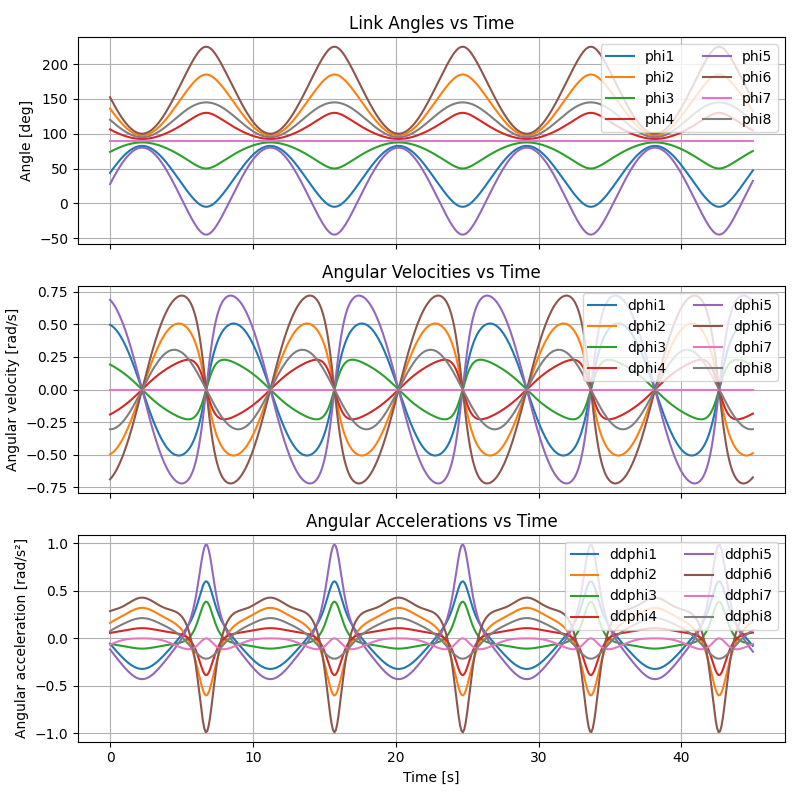

In [104]:


angles = [phi1, phi2, phi3, phi4, phi5, phi6, phi7, phi8]
velocities = [dphi1, dphi2, dphi3, dphi4, dphi5, dphi6, dphi7, dphi8]
accelerations = [ddphi1, ddphi2, ddphi3, ddphi4, ddphi5, ddphi6, ddphi7, ddphi8]

fig, axes = plt.subplots(3, 1, figsize=(8, 8), sharex=True)

for i, phi in enumerate(angles, start=1):
    axes[0].plot(t, np.degrees(phi), label=f'phi{i}')
axes[0].set_ylabel('Angle [deg]')
axes[0].set_title('Link Angles vs Time')
axes[0].legend(loc='upper right', ncol=2)
axes[0].grid(True)

for i, omega in enumerate(velocities, start=1):
    axes[1].plot(t, omega, label=f'dphi{i}')
axes[1].set_ylabel('Angular velocity [rad/s]')
axes[1].set_title('Angular Velocities vs Time')
axes[1].legend(loc='upper right', ncol=2)
axes[1].grid(True)

for i, alpha in enumerate(accelerations, start=1):
    axes[2].plot(t, alpha, label=f'ddphi{i}')
axes[2].set_ylabel('Angular acceleration [rad/s²]')
axes[2].set_xlabel('Time [s]')
axes[2].set_title('Angular Accelerations vs Time')
axes[2].legend(loc='upper right', ncol=2)
axes[2].grid(True)

plt.tight_layout()
plt.show()



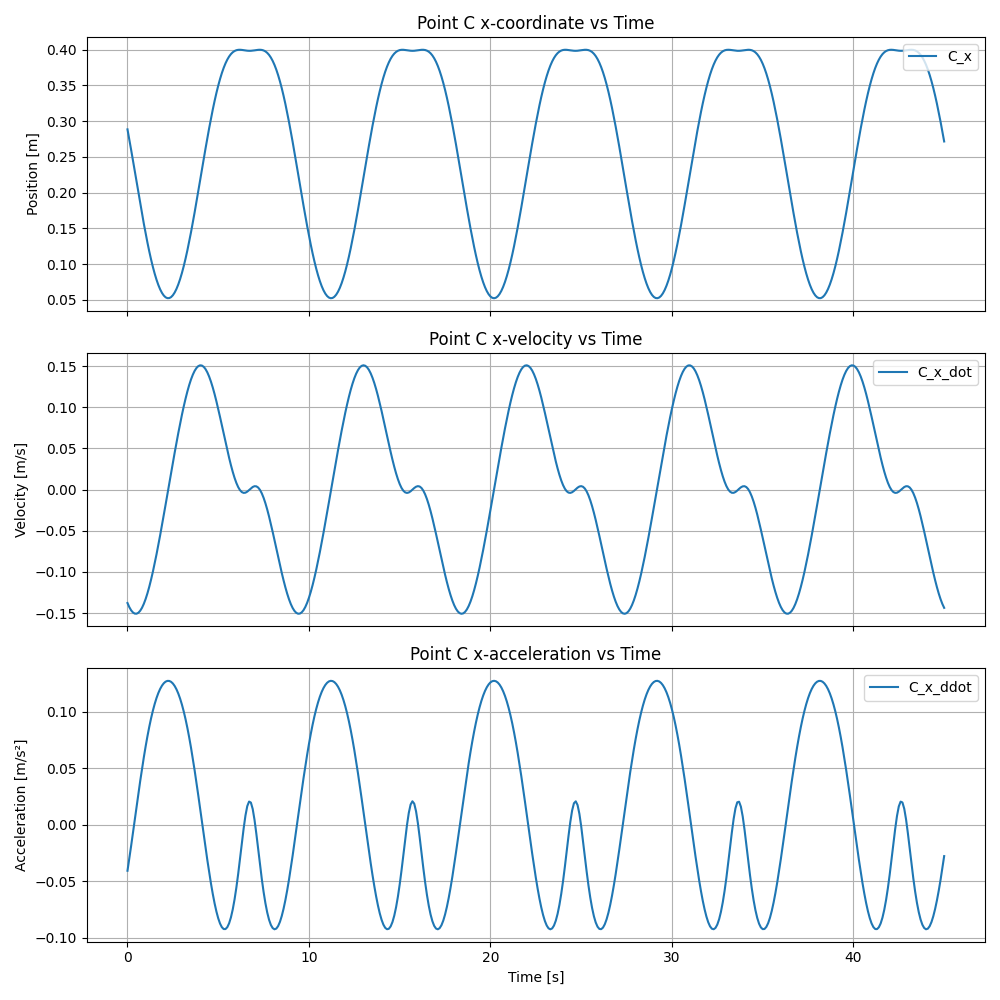

In [105]:
# Plot the x-coordinate of point C and its x-direction velocity and acceleration
C_x = r1 * np.cos(phi1) - r2 * np.cos(phi2)
C_x_dot = -r1 * np.sin(phi1) * dphi1 + r2 * np.sin(phi2) * dphi2
C_x_ddot = -r1 * np.cos(phi1) * dphi1**2 - r1 * np.sin(phi1) * ddphi1 + r2 * np.cos(phi2) * dphi2**2 + r2 * np.sin(phi2) * ddphi2

fig, axes = plt.subplots(3, 1, figsize=(10, 10), sharex=True)
axes[0].plot(t, C_x, label='C_x')
axes[0].set_ylabel('Position [m]')
axes[0].set_title('Point C x-coordinate vs Time')
axes[0].legend(loc='upper right')
axes[0].grid(True)

axes[1].plot(t, C_x_dot, label='C_x_dot')
axes[1].set_ylabel('Velocity [m/s]')
axes[1].set_title('Point C x-velocity vs Time')
axes[1].legend(loc='upper right')
axes[1].grid(True)

axes[2].plot(t, C_x_ddot, label='C_x_ddot')
axes[2].set_ylabel('Acceleration [m/s²]')
axes[2].set_xlabel('Time [s]')
axes[2].set_title('Point C x-acceleration vs Time')
axes[2].legend(loc='upper right')
axes[2].grid(True)

plt.tight_layout()
plt.show()  

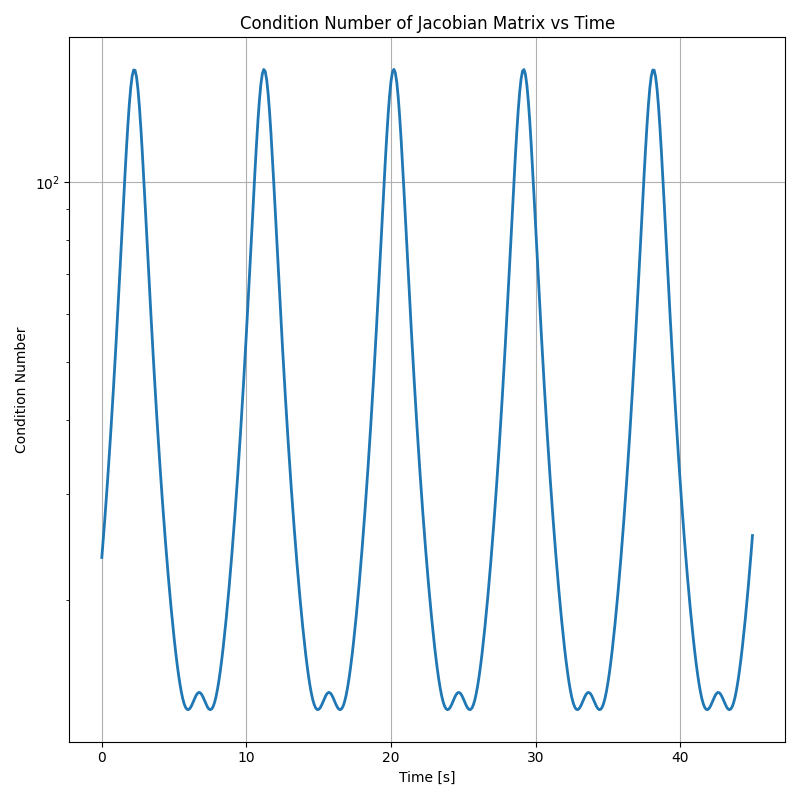

In [106]:
# Plot the condition number of the Jacobian matrix
fig, ax = plt.subplots(figsize=(8, 8))
ax.plot(t, cond, linewidth=2)
ax.set_ylabel('Condition Number')
ax.set_xlabel('Time [s]')
ax.set_title('Condition Number of Jacobian Matrix vs Time')
ax.grid(True)
ax.set_yscale('log')
plt.tight_layout()
plt.show()

<div style="width: 100%; font-size: 0.80em; overflow-x:auto;">
<a id="matrixmethode"></a>

$$

 \begin{pmatrix}
 0 & 1 & 0 & 1 & 0 & 1 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0\\
 0 & 0 & 1 & 0 & 1 & 0 & 1 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0\\
 -1 & -L_{BH} \cdot c_{\phi1} & L_{BH} \cdot s_{\phi1} & -L_{FH} \cdot c_{\phi1} & L_{FH} \cdot s_{\phi1} & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0\\
 0 & -1 & 0 & 0 & 0 & 0 & 0 & 1 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0\\
 0 & 0 & -1 & 0 & 0 & 0 & 0 & 0 & 1 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0\\
 0 & -1/2 \cdot L_{AB} \cdot c_{\phi2} & 1/2 \cdot L_{AB} \cdot s_{\phi2} & 0 & 0 & 0 & 0 & -1/2 \cdot L_{AB} \cdot c_{\phi2} & 1/2 \cdot L_{AB} \cdot s_{\phi2} & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0\\
 0 & 0 & 0 & -1 & 0 & 0 & 0 & 0 & 0 & 1 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0\\
 0 & 0 & 0 & 0 & -1 & 0 & 0 & 0 & 0 & 0 & 1 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0\\
 0 & 0 & 0 & -1/2 \cdot L_{DF} \cdot c_{\phi4} & 1/2 \cdot L_{DF} \cdot s_{\phi4} & 0 & 0 & 0 & 0 & -1/2 \cdot L_{DF} \cdot c_{\phi4} & 1/2 \cdot L_{DF} \cdot s_{\phi4} & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0\\
 0 & 0 & 0 & 0 & 0 & -1 & 0 & 0 & 0 & 0 & 0 & 1 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0\\
 0 & 0 & 0 & 0 & 0 & 0 & -1 & 0 & 0 & 0 & 0 & 0 & 1 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0\\
 1 & 0 & 0 & 0 & 0 & -1/2 \cdot L_{EH} \cdot c_{\phi6} & 1/2 \cdot L_{EH} \cdot s_{\phi6} & 0 & 0 & 0 & 0 & -1/2 \cdot L_{EH} \cdot c_{\phi6} & 1/2 \cdot L_{EH} \cdot s_{\phi6} & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0\\
 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 1 & 0 & 1 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0\\
 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 1 & 0 & 1 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0\\
 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & -1/2 \cdot L_{AD} \cdot c_{\phi3} & 1/2 \cdot L_{AD} \cdot s_{\phi3} & 1/2 \cdot L_{AD} \cdot c_{\phi3} & -1/2 \cdot L_{AD} \cdot s_{\phi3} & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0\\
 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 1 & 0 & 1 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0\\
 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 1 & 0 & 1 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0\\
 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & -1/2 \cdot L_{AE} \cdot c_{\phi3} & -1/2 \cdot L_{AE} \cdot s_{\phi3} & 1/2 \cdot L_{AE} \cdot c_{\phi3} & 1/2 \cdot L_{AE} \cdot s_{\phi3} & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0\\
 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 1 & 0 & 0 & 0 & 0 & 0 & 1 & 0 & 0 & 0 & 0 & 0\\
 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 1 & 0 & 0 & 0 & 0 & 0 & 1 & 0 & 0 & 0 & 0\\
 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & -1/2 \cdot L_{AC} \cdot c_{\phi2} & -1/2 \cdot L_{AC} \cdot s_{\phi2} & 0 & 0 & 0 & 0 & 1/2 \cdot L_{AC} \cdot c_{\phi2} & 1/2 \cdot L_{AC} \cdot s_{\phi2} & 0 & 0 & 0 & 0\\
 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 1 & 0 & 0 & 0 & 0 & 0 & 1 & 0 & 0 & 0\\
 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 1 & 0 & 0 & 0 & 0 & 0 & 1 & 0 & 0\\
 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & -1/2 \cdot L_{EG} \cdot c_{\phi4} & -1/2 \cdot L_{EG} \cdot s_{\phi4} & 0 & 0 & 0 & 0 & 1/2 \cdot L_{EG} \cdot c_{\phi4} & 1/2 \cdot L_{EG} \cdot s_{\phi4} & 0 & 0\\
 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 1 & 0 & 0 & 0 & 0 & 0 & 1 & 0\\
 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 1 & 0 & 0 & 0 & 0 & 0 & 1\\
 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & -1/2 \cdot L_{DI} \cdot c_{\phi6} & -1/2 \cdot L_{DI} \cdot s_{\phi6} & 0 & 0 & 0 & 0 & 1/2 \cdot L_{DI} \cdot c_{\phi6} & 1/2 \cdot L_{DI} \cdot s_{\phi6}\\ 
 0 & 0 & 0 & 0 & 0 & 0 & 0 & 1 & 0 & 0 & 0 & 0 & 0 & 1 & 0 & 0 & 0 & 1 & 0 & 0 & 0 & 1 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0\\
 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 1 & 0 & 0 & 0 & 0 & 0 & 1 & 0 & 0 & 0 & 1 & 0 & 0 & 0 & 1 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0\\
 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 1 & 0 & 0 & 0 & 0 & 0 & 1 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 1 & 0 & 0 & 0 & 0 & 0 & 0 & 0\\
 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 1 & 0 & 0 & 0 & 0 & 0 & 1 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 1 & 0 & 0 & 0 & 0 & 0 & 0\\
 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 1 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 1 & 0 & 0 & 0 & 1 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0\\
 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 1 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 1 & 0 & 0 & 0 & 1 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0
 \end{pmatrix}

 \begin{pmatrix}
 M_{h}\\F_{g1x} \\ F_{g1y} \\ F_{g5x} \\ F_{g5y} \\ F_{g9x} \\ F_{g9y} \\ F_{1ax} \\ F_{1ay} \\ F_{5dx} \\ F_{5dy} \\ F_{9ex} \\ F_{9ey} \\ F_{3ax} \\ F_{3ay} \\ F_{3dx} \\ F_{3dy} \\ F_{4ax} \\ F_{4ay} \\ F_{4ex} \\ F_{4ey} \\ F_{2ax} \\ F_{2ay} \\ F_{6ex} \\ F_{6ey} \\ F_{8dx} \\ F_{8dy} \\ F_{27x} \\ F_{27y} \\ F_{67x} \\ F_{67y} \\ F_{87x} \\ F_{87y}
 \end{pmatrix}
 =
 \begin{pmatrix}
  0 \\ 0 \\ 0 \\ m_{AB} \cdot a_{ABx} \\ m_{AB} \cdot a_{ABy} \\ I_{AB} \cdot \alpha_{2} \\ m_{DF} \cdot a_{DFx} \\ m_{DF} \cdot a_{DFy} \\ I_{DF} \cdot \alpha_{4} \\ m_{EH} \cdot a_{EHx} \\ m_{EH} \cdot a_{EHy} \\ I_{EH} \cdot \alpha_{6} \\ m_{AD} \cdot a_{ADx} \\ m_{AD} \cdot a_{ADy} \\ I_{AD} \cdot \alpha_{3} \\ m_{AE} \cdot a_{AEx} \\ m_{AE} \cdot a_{AEy} \\ I_{AE} \cdot \alpha_{3} \\ m_{AC} \cdot a_{ACx} \\ m_{AC} \cdot a_{ACy}\\ I_{AC} \cdot \alpha_{2} \\m_{EG} \cdot a_{EGx} \\ m_{EG} \cdot a_{EGy} \\ I_{EG} \cdot \alpha_{4} \\ m_{DI} \cdot a_{DIx} \\ m_{DI} \cdot a_{DIy} \\ I_{DI} \cdot \alpha_{6} \\ 0 \\ 0 \\ 0 \\ 0 \\ 0 \\ 0
 \end{pmatrix}
$$

</div>

letters zijn punten (buiten ground), getallen zijn stangen


NameError: name 'lengths' is not defined